# MobileNetV3-Small: Document Readability Classifier

**Objective:** Binary classification — apakah teks dokumen Readable (0) atau Unreadable (1). <br>
**Target Deployment:** Cloud Free Tier (1 vCPU, <1GB RAM) via ONNX Runtime. <br>
**Pipeline Position:** Model 2 — menerima gambar hasil crop+warp+CLAHE dari Model 1 (YOLO11n-OBB). <br>
**Input:** 224×224 BGR (sudah CLAHE-preprocessed, saved as files). <br>

---

### Notebook Structure
1. Environment Setup
2. Dataset Verification & EDA
3. DataLoader Pipeline
4. Model Architecture & Training Strategy
5. Phase 1: Head-Only Training (Backbone Frozen)
6. Phase 2: Full Fine-Tuning (Backbone Unfrozen)
7. Evaluation on Test Set
8. ONNX Export
9. ONNX Runtime Inference Pipeline (Production-Ready)
10. End-to-End Integration Test

## 1. Environment Setup

In [25]:
import os
import copy
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import MobileNet_V3_Small_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    f1_score,
)

import wandb
import optuna
from optuna.exceptions import TrialPruned

# REPRODUCIBILITY SETUP
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# DETECT DEVICE
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    print(f"VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
Device:  cuda
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:    8.6 GB


## 2. Dataset Verification & EDA

In [26]:
# Path Configuration
# Struktur dataset:
#   dataset/final_split/model2_classification/
#     train/
#       0_readable/
#       1_unreadable/
#     val/
#       0_readable/
#       1_unreadable/
#     test/
#       0_readable/
#       1_unreadable/

DATASET_ROOT = Path("../dataset/final_split/model2_clf")
CLASS_NAMES = ['0_readable', '1_unreadable']
LABEL_MAP = {'0_readable': 0, '1_unreadable': 1}  # 0=readable, 1=unreadable
IMGSZ = 224  # MobileNetV3 standard input

# Validasi struktur
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        p = DATASET_ROOT / split / cls
        assert p.exists(), f"Directory tidak ditemukan: {p}"

print("Dataset structure verified")

Dataset structure verified


In [27]:
# Dataset Statistics

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

print("=" * 55)
print(f"{'Split':<8} {'Readable':>10} {'Unreadable':>12} {'Total':>8} {'Ratio':>8}")
print("-" * 55)

split_counts = {}
for split in ['train', 'val', 'test']:
    counts = {}
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        n = len([f for f in folder.iterdir() if f.suffix.lower() in IMG_EXTS])
        counts[cls] = n
    total = sum(counts.values())
    ratio = counts['0_readable'] / counts['1_unreadable'] if counts['1_unreadable'] > 0 else float('inf')
    split_counts[split] = counts
    print(f"{split:<8} {counts['0_readable']:>10} {counts['1_unreadable']:>12} {total:>8} {ratio:>7.2f}")

print("=" * 55)

# Check balance
train_r = split_counts['train']['0_readable']
train_u = split_counts['train']['1_unreadable']
if abs(train_r - train_u) / max(train_r, train_u) < 0.1:
    print("Classes are balanced")
else:
    print(f"Classes imbalanced: {train_r} vs {train_u}")

Split      Readable   Unreadable    Total    Ratio
-------------------------------------------------------
train           260          260      520    1.00
val              56           56      112    1.00
test             56           56      112    1.00
Classes are balanced


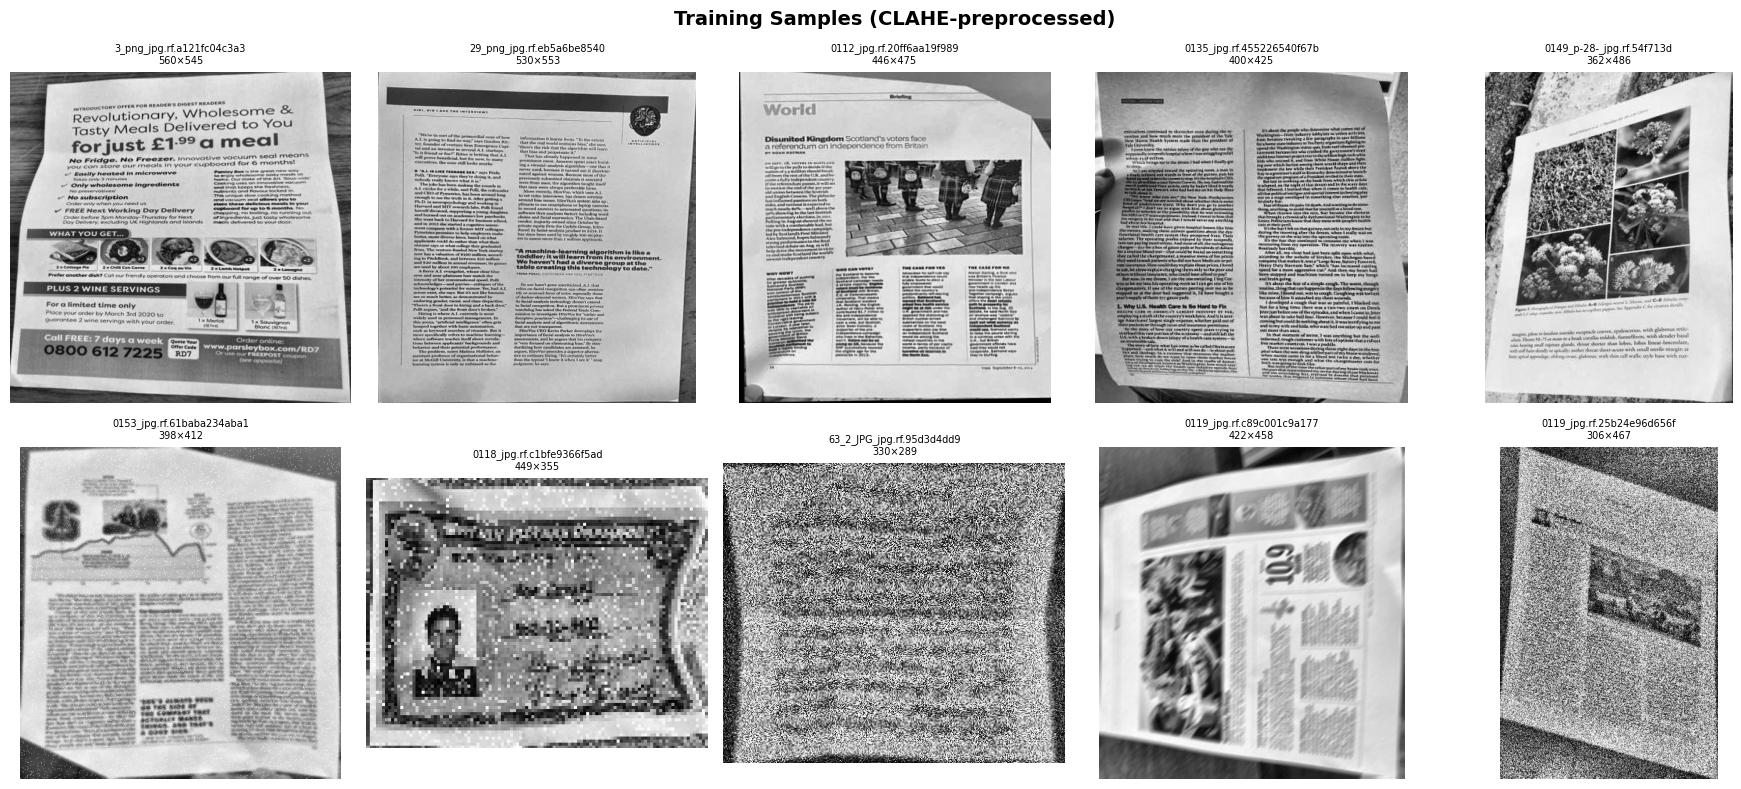

In [28]:
# Visual Samples: Readable vs Unreadable

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row, cls in enumerate(CLASS_NAMES):
    folder = DATASET_ROOT / 'train' / cls
    all_imgs = [f for f in folder.iterdir() if f.suffix.lower() in IMG_EXTS]
    samples = random.sample(all_imgs, min(5, len(all_imgs)))
    
    for col, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img_rgb)
        axes[row, col].set_title(f"{img_path.name[:25]}\n{img.shape[1]}×{img.shape[0]}", fontsize=7)
        axes[row, col].axis('off')
    
    # Row label
    label = 'READABLE' if cls == '0_readable' else 'UNREADABLE'
    axes[row, 0].set_ylabel(label, fontsize=12, fontweight='bold', rotation=0, labelpad=80)

plt.suptitle('Training Samples (CLAHE-preprocessed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. DataLoader Pipeline

### Preprocessing Rationale

Data sudah melalui CLAHE alignment (Grayscale → CLAHE → BGR) di pipeline sebelumnya.  
Saat training, kita hanya perlu:
1. **Resize** ke 224×224 (MobileNetV3 input)
2. **Normalize** dengan ImageNet mean/std (karena pretrained weights dari ImageNet)
3. **Minimal augmentation** — hanya horizontal flip + slight color jitter, karena augmentasi destruktif sudah dilakukan saat data preparation

Tidak perlu augmentasi berat karena data `1_unreadable` sudah di-generate dengan Albumentations (blur, noise, compression).

In [29]:
class DocumentReadabilityDataset(Dataset):
    """Binary classification dataset: 0=readable, 1=unreadable."""
    
    def __init__(self, root_dir, split, transform=None):
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.samples = []  # list of (path, label)
        
        for cls_name, label in LABEL_MAP.items():
            cls_dir = self.root_dir / cls_name
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in IMG_EXTS:
                    self.samples.append((str(img_path), label))
        
        random.shuffle(self.samples)
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Read BGR → RGB
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize ke 224×224 (beberapa gambar mungkin berbeda ukuran)
        img = cv2.resize(img, (IMGSZ, IMGSZ), interpolation=cv2.INTER_LINEAR)
        
        if self.transform:
            from PIL import Image
            img = Image.fromarray(img)
            img = self.transform(img)
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        return img, torch.tensor(label, dtype=torch.float32)

print("DocumentReadabilityDataset defined")

DocumentReadabilityDataset defined


In [30]:
# Normalization

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Sangat ringan
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Create Datasets
train_dataset = DocumentReadabilityDataset(DATASET_ROOT, 'train', transform=train_transform)
val_dataset = DocumentReadabilityDataset(DATASET_ROOT, 'val', transform=val_transform)
test_dataset = DocumentReadabilityDataset(DATASET_ROOT, 'test', transform=val_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

# Quick sanity check
batch_imgs, batch_labels = next(iter(train_loader))
print(f"Batch shape: {batch_imgs.shape} | Labels: {batch_labels[:8].tolist()}")

Train: 520 | Val: 112 | Test: 112
Batch shape: torch.Size([32, 3, 224, 224]) | Labels: [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0]


## 4. Model Architecture & Training Strategy

### Two-Phase Transfer Learning

Ref: *How transferable are features in deep neural networks?* (Yosinski et al., 2014, NeurIPS)  
Ref: *Fine-tuning deep learning*, PyTorch official tutorial  

| Phase | Apa yang dilatih | LR | Epochs | Tujuan |
|-------|-----------------|-----|--------|--------|
| **Phase 1** | Classifier head saja | 1e-3 | 10 | Warmup: adaptasi head ke domain baru tanpa merusak pretrained features |
| **Phase 2** | Seluruh network | 1e-4 (backbone) / 5e-4 (head) | 30 | Fine-tune: adaptasi backbone features ke texture & pattern dokumen |

### Kenapa Binary (BCEWithLogitsLoss) bukan CrossEntropy?
- Untuk 2 kelas, BCE dengan 1 output neuron lebih efisien dari CE dengan 2 neuron
- Sigmoid output langsung interpretable sebagai probabilitas
- ONNX export lebih clean: 1 output → sigmoid → threshold

### Classifier Head Design
```
MobileNetV3-Small backbone (features)  →  [576 channels]
  → AdaptiveAvgPool2d(1)                →  [576]
  → Linear(576, 1024) + Hardswish       →  [1024]  (kept from original)
  → Dropout(0.3)                        →  [1024]  (increased from 0.2)
  → Linear(1024, 1)                     →  [1]     (replaced: 1000 → 1)
```

In [31]:
# === Build Model ===

def build_model():
    """
    MobileNetV3-Small dengan classifier head di-modify untuk binary classification.
    
    Original classifier:
      (0): Linear(576, 1024)
      (1): Hardswish()
      (2): Dropout(p=0.2)
      (3): Linear(1024, 1000)
    
    Modified:
      (0): Linear(576, 1024)   ← keep (pretrained projection)
      (1): Hardswish()         ← keep
      (2): Dropout(p=0.3)     ← increased untuk regularisasi
      (3): Linear(1024, 1)    ← replaced (binary output)
    """
    model = models.mobilenet_v3_small(
        weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1
    )
    
    # Modify classifier head
    model.classifier[2] = nn.Dropout(p=0.3)       # Increase dropout
    model.classifier[3] = nn.Linear(1024, 1)      # Binary output
    
    # Initialize new layer
    nn.init.xavier_uniform_(model.classifier[3].weight)
    nn.init.zeros_(model.classifier[3].bias)
    
    return model

model = build_model().to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size (est):     ~{total_params * 4 / 1e6:.1f} MB (FP32)")

Total parameters:     1,518,881
Trainable parameters: 1,518,881
Model size (est):     ~6.1 MB (FP32)


In [32]:
# === Training Utilities ===

def freeze_backbone(model):
    """Freeze everything except classifier head."""
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    # BN layers: eval mode saat backbone frozen
    # (mencegah running mean/var update dari small batch)
    model.features.eval()

def unfreeze_backbone(model):
    """Unfreeze seluruh model."""
    for param in model.parameters():
        param.requires_grad = True
    model.train()

def train_one_epoch(model, loader, criterion, optimizer, device, backbone_frozen=False):
    """Train satu epoch."""
    if backbone_frozen:
        model.features.eval()    # BN tetap eval saat frozen
        model.classifier.train()
    else:
        model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)  # (B,) → (B, 1)
        
        optimizer.zero_grad()
        outputs = model(images)  # (B, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_probs), np.array(all_labels)

print("Training utilities defined")

Training utilities defined


## 4b. Hyperparameter Optimization (Optuna)

Mencari kombinasi optimal untuk:
- **Phase 1 LR** (head-only warmup)
- **Phase 2 LR backbone & head** (differential LR)
- **Dropout rate** di classifier head
- **Batch size**
- **Weight decay**

Strategi: Setiap trial menjalankan Phase 1 (5 epoch) + Phase 2 (15 epoch, early stop patience=5).
Metric target: **Val ROC-AUC** (lebih robust dari accuracy untuk binary classification).
Pruning: MedianPruner memotong trial yang underperform di tengah jalan.

In [33]:
# === Optuna Hyperparameter Optimization ===

N_TRIALS = 20          # Jumlah trial Optuna
HPO_P1_EPOCHS = 5      # Phase 1 epochs per trial (reduced)
HPO_P2_EPOCHS = 15     # Phase 2 epochs per trial (reduced)
HPO_PATIENCE = 5       # Early stopping patience per trial


def objective(trial):
    """Optuna objective: maximize val ROC-AUC."""

    # ── Sample hyperparameters ──────────────────────────────────────
    dropout = trial.suggest_float("dropout", 0.2, 0.5, step=0.05)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    p1_lr = trial.suggest_float("p1_lr", 5e-4, 5e-3, log=True)
    p2_lr_backbone = trial.suggest_float("p2_lr_backbone", 1e-5, 5e-4, log=True)
    p2_lr_head = trial.suggest_float("p2_lr_head", 1e-4, 2e-3, log=True)

    # ── Build model ─────────────────────────────────────────────────
    m = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    m.classifier[2] = nn.Dropout(p=dropout)
    m.classifier[3] = nn.Linear(1024, 1)
    nn.init.xavier_uniform_(m.classifier[3].weight)
    nn.init.zeros_(m.classifier[3].bias)
    m = m.to(DEVICE)

    # ── DataLoaders (batch_size varies) ─────────────────────────────
    tl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    vl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)

    crit = nn.BCEWithLogitsLoss()

    # ── Phase 1: Head only ──────────────────────────────────────────
    freeze_backbone(m)
    opt1 = optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()),
                       lr=p1_lr, weight_decay=weight_decay)
    sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=HPO_P1_EPOCHS)

    for ep in range(HPO_P1_EPOCHS):
        train_one_epoch(m, tl, crit, opt1, DEVICE, backbone_frozen=True)
        sch1.step()

    # ── Phase 2: Full fine-tune ─────────────────────────────────────
    unfreeze_backbone(m)
    opt2 = optim.AdamW([
        {"params": m.features.parameters(), "lr": p2_lr_backbone},
        {"params": m.classifier.parameters(), "lr": p2_lr_head},
    ], weight_decay=weight_decay)
    sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=HPO_P2_EPOCHS)

    best_auc = 0.0
    wait = 0

    for ep in range(HPO_P2_EPOCHS):
        train_one_epoch(m, tl, crit, opt2, DEVICE, backbone_frozen=False)
        _, _, val_probs, val_labels = evaluate(m, vl, crit, DEVICE)
        sch2.step()

        val_auc = roc_auc_score(val_labels, val_probs)

        # Report to Optuna for pruning
        trial.report(val_auc, ep)
        if trial.should_prune():
            raise TrialPruned()

        if val_auc > best_auc:
            best_auc = val_auc
            wait = 0
        else:
            wait += 1
            if wait >= HPO_PATIENCE:
                break

    return best_auc


# ── Run HPO ─────────────────────────────────────────────────────────
study = optuna.create_study(
    direction="maximize",
    study_name="readability_classifier_hpo",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# ── Results ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("OPTUNA HPO RESULTS")
print("=" * 60)
print(f"  Best ROC-AUC: {study.best_value:.4f}")
print(f"  Best params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# Save for use in training
BEST_HP = study.best_params

[I 2026-05-06 12:39:19,631] A new study created in memory with name: readability_classifier_hpo
Best trial: 0. Best value: 0.999043:   5%|▌         | 1/20 [01:09<21:53, 69.13s/it]

[I 2026-05-06 12:40:28,762] Trial 0 finished with value: 0.9990433673469388 and parameters: {'dropout': 0.45, 'batch_size': 32, 'weight_decay': 0.00040764413914231044, 'p1_lr': 0.0006673762579603236, 'p2_lr_backbone': 0.00016455274091152296, 'p2_lr_head': 0.0002615406850227013}. Best is trial 0 with value: 0.9990433673469388.


Best trial: 1. Best value: 1:  10%|█         | 2/20 [02:11<19:28, 64.89s/it]       

[I 2026-05-06 12:41:30,688] Trial 1 finished with value: 1.0 and parameters: {'dropout': 0.5, 'batch_size': 32, 'weight_decay': 0.0001905080855737911, 'p1_lr': 0.0005844043311479347, 'p2_lr_backbone': 0.000380105401668463, 'p2_lr_head': 0.00028166131254415554}. Best is trial 1 with value: 1.0.


Best trial: 1. Best value: 1:  15%|█▌        | 3/20 [02:58<16:07, 56.91s/it]

...

[I 2026-05-06 12:50:19,630] Trial 17 pruned. 


Best trial: 1. Best value: 1:  95%|█████████▌| 19/20 [11:47<00:33, 33.61s/it]

[I 2026-05-06 12:51:06,654] Trial 18 finished with value: 0.9990433673469388 and parameters: {'dropout': 0.45, 'batch_size': 32, 'weight_decay': 0.0009986999121131528, 'p1_lr': 0.0005114763399831675, 'p2_lr_backbone': 0.0002702314965977652, 'p2_lr_head': 0.00107436934795826}. Best is trial 1 with value: 1.0.


Best trial: 1. Best value: 1: 100%|██████████| 20/20 [12:10<00:00, 36.54s/it]

[I 2026-05-06 12:51:30,358] Trial 19 pruned. 

OPTUNA HPO RESULTS
  Best ROC-AUC: 1.0000
  Best params:
    dropout: 0.5
    batch_size: 32
    weight_decay: 0.0001905080855737911
    p1_lr: 0.0005844043311479347
    p2_lr_backbone: 0.000380105401668463
    p2_lr_head: 0.00028166131254415554


## 5. Phase 1: Head-Only Training (Backbone Frozen)

Freeze backbone → train classifier head saja.  
Tujuan: adaptasi head layer ke distribusi data baru tanpa merusak pretrained features.

In [34]:
# === Phase 1 Config (using Optuna best params) ===
PHASE1_EPOCHS = 10
PHASE1_LR = BEST_HP['p1_lr']

# ── W&B Init ────────────────────────────────────────────────────────
wandb.init(
    project="MitBridge",
    name="clf_mobilenetv3_best",
    config={
        "model": "MobileNetV3-Small",
        "phase1_epochs": PHASE1_EPOCHS,
        "phase2_epochs": 30,
        "patience": 8,
        **BEST_HP,  # All Optuna best params logged automatically
    },
)

# ── Rebuild model with best dropout ─────────────────────────────────
model = build_model()
# Override dropout with Optuna's best
model.classifier[2] = nn.Dropout(p=BEST_HP['dropout'])
nn.init.xavier_uniform_(model.classifier[3].weight)
nn.init.zeros_(model.classifier[3].bias)
model = model.to(DEVICE)

# ── Rebuild dataloaders with best batch size ────────────────────────
BATCH_SIZE = BEST_HP['batch_size']
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

# Freeze backbone
freeze_backbone(model)

trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 — Trainable params: {trainable_p1:,} (classifier head only)")

# Loss & Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR,
    weight_decay=BEST_HP['weight_decay'],
)

# LR Scheduler
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=PHASE1_EPOCHS)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/gradi/.netrc.
wandb: Currently logged in as: gradienridholumintu555306 (gradienridholumintu555306-universitas-gadjah-mada-library) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run zrvbq676
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/gradi/projects/MitBridge/wandb/run-20260506_125131-zrvbq676
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run clf_mobilenetv3_best
wandb: ⭐️ View project at https://wandb.ai/gradienridholumintu555306-universitas-gadjah-mada-library/MitBridge
wandb: 🚀 View run at https://wandb.ai/gradienridholumintu555306-universitas-gadjah-mada-library/MitBridge/runs/zrvbq676


Phase 1 — Trainable params: 591,873 (classifier head only)


In [35]:
# === Phase 1 Training Loop ===

history_p1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_p1 = 0.0

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9} {'LR':>10}")
print("-" * 62)

for epoch in range(PHASE1_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_p1, DEVICE, backbone_frozen=True
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler_p1.step()
    current_lr = optimizer_p1.param_groups[0]['lr']

    history_p1['train_loss'].append(train_loss)
    history_p1['train_acc'].append(train_acc)
    history_p1['val_loss'].append(val_loss)
    history_p1['val_acc'].append(val_acc)

    # W&B logging
    wandb.log({
        "phase": 1,
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/acc": train_acc,
        "val/loss": val_loss,
        "val/acc": val_acc,
        "lr": current_lr,
    })

    if val_acc > best_val_acc_p1:
        best_val_acc_p1 = val_acc

    elapsed = time.time() - t0
    print(f"  {epoch+1:>3}/{PHASE1_EPOCHS}   {train_loss:>9.4f}   {train_acc:>8.4f}   {val_loss:>8.4f}   {val_acc:>7.4f}   {current_lr:.2e}")

print(f"\nPhase 1 Best Val Acc: {best_val_acc_p1:.4f}")

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc         LR
--------------------------------------------------------------
    1/10      0.3905     0.8203     0.2119    0.9018   5.70e-04
    2/10      0.1719     0.9297     0.1615    0.9464   5.29e-04
    3/10      0.1367     0.9395     0.1401    0.9554   4.64e-04
    4/10      0.0962     0.9707     0.1144    0.9643   3.82e-04
    5/10      0.0677     0.9844     0.1111    0.9554   2.92e-04
    6/10      0.0704     0.9766     0.0957    0.9643   2.02e-04
    7/10      0.0587     0.9863     0.0915    0.9643   1.20e-04
    8/10      0.0518     0.9922     0.0915    0.9643   5.58e-05
    9/10      0.0674     0.9727     0.0891    0.9643   1.43e-05
   10/10      0.0606     0.9805     0.0888    0.9643   0.00e+00

Phase 1 Best Val Acc: 0.9643


## 6. Phase 2: Full Fine-Tuning

Unfreeze backbone → fine-tune seluruh network dengan **differential LR**:  
- Backbone: 1e-4 (low LR agar pretrained features tidak rusak)  
- Classifier head: 5e-4 (higher LR karena head perlu lebih banyak adaptasi)  

Ref: *Discriminative fine-tuning* (Howard & Ruder, 2018, ULMFiT, ACL)

In [36]:
# === Phase 2 Config (using Optuna best params) ===
PHASE2_EPOCHS = 30
PHASE2_LR_BACKBONE = BEST_HP['p2_lr_backbone']
PHASE2_LR_HEAD = BEST_HP['p2_lr_head']
PATIENCE = 8

# Unfreeze backbone
unfreeze_backbone(model)

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 — Trainable params: {trainable_p2:,} (full model)")

# Differential LR
optimizer_p2 = optim.AdamW([
    {'params': model.features.parameters(), 'lr': PHASE2_LR_BACKBONE},
    {'params': model.classifier.parameters(), 'lr': PHASE2_LR_HEAD},
], weight_decay=BEST_HP['weight_decay'])

# Cosine annealing
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS)

Phase 2 — Trainable params: 1,518,881 (full model)


In [37]:
# === Phase 2 Training Loop with Early Stopping ===

history_p2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_p2 = 0.0
best_model_state = None
patience_counter = 0

# Output directory
SAVE_DIR = Path('../runs/classification/document_readability')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9} {'LR(bb)':>10} {'Status':>8}")
print("-" * 72)

for epoch in range(PHASE2_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_p2, DEVICE, backbone_frozen=False
    )
    val_loss, val_acc, val_probs_ep, val_labels_ep = evaluate(model, val_loader, criterion, DEVICE)

    scheduler_p2.step()
    current_lr = optimizer_p2.param_groups[0]['lr']

    history_p2['train_loss'].append(train_loss)
    history_p2['train_acc'].append(train_acc)
    history_p2['val_loss'].append(val_loss)
    history_p2['val_acc'].append(val_acc)

    # Compute val ROC-AUC
    val_auc = roc_auc_score(val_labels_ep, val_probs_ep)

    # W&B logging
    wandb.log({
        "phase": 2,
        "epoch": PHASE1_EPOCHS + epoch + 1,
        "train/loss": train_loss,
        "train/acc": train_acc,
        "val/loss": val_loss,
        "val/acc": val_acc,
        "val/roc_auc": val_auc,
        "lr_backbone": current_lr,
        "lr_head": optimizer_p2.param_groups[1]['lr'],
    })

    # Best model tracking
    status = ''
    if val_acc > best_val_acc_p2:
        best_val_acc_p2 = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, SAVE_DIR / 'best.pt')
        patience_counter = 0
        status = 'best'
    else:
        patience_counter += 1
        status = f'wait {patience_counter}/{PATIENCE}'

    print(f"  {epoch+1:>3}/{PHASE2_EPOCHS}   {train_loss:>9.4f}   {train_acc:>8.4f}   {val_loss:>8.4f}   {val_acc:>7.4f}   {current_lr:.2e}  {status}")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nBest model loaded (Val Acc: {best_val_acc_p2:.4f})")

 Epoch  Train Loss  Train Acc   Val Loss   Val Acc     LR(bb)   Status
------------------------------------------------------------------------
    1/30      0.1814     0.9277     0.2292    0.9286   3.79e-04  best
    2/30      0.0600     0.9785     0.0754    0.9732   3.76e-04  best
    3/30      0.0387     0.9824     0.0650    0.9732   3.71e-04  wait 1/8
    4/30      0.0448     0.9863     0.0289    0.9911   3.64e-04  best
    5/30      0.0220     0.9980     0.0312    0.9821   3.55e-04  wait 1/8
    6/30      0.0099     0.9961     0.0525    0.9821   3.44e-04  wait 2/8
    7/30      0.0076     0.9980     0.0497    0.9732   3.31e-04  wait 3/8
    8/30      0.0058     1.0000     0.0503    0.9911   3.17e-04  wait 4/8
    9/30      0.0049     0.9980     0.0611    0.9821   3.02e-04  wait 5/8
   10/30      0.0035     1.0000     0.0263    0.9821   2.85e-04  wait 6/8
   11/30      0.0177     0.9922     0.0130    0.9911   2.67e-04  wait 7/8
   12/30      0.0246     0.9941     0.0391    0.9821  

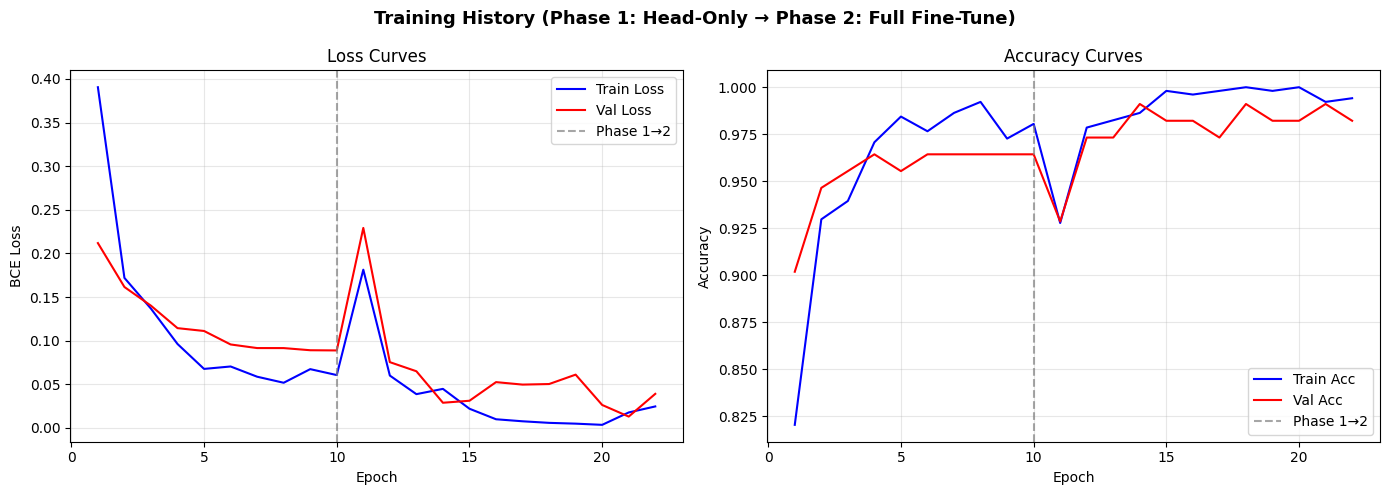

In [38]:
# === Training Curves (Phase 1 + Phase 2) ===

# Gabungkan history
full_train_loss = history_p1['train_loss'] + history_p2['train_loss']
full_val_loss = history_p1['val_loss'] + history_p2['val_loss']
full_train_acc = history_p1['train_acc'] + history_p2['train_acc']
full_val_acc = history_p1['val_acc'] + history_p2['val_acc']
phase1_end = len(history_p1['train_loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(full_train_loss) + 1)

# Loss
ax1.plot(epochs_range, full_train_loss, 'b-', label='Train Loss', linewidth=1.5)
ax1.plot(epochs_range, full_val_loss, 'r-', label='Val Loss', linewidth=1.5)
ax1.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 1→2')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, full_train_acc, 'b-', label='Train Acc', linewidth=1.5)
ax2.plot(epochs_range, full_val_acc, 'r-', label='Val Acc', linewidth=1.5)
ax2.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 1→2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History (Phase 1: Head-Only → Phase 2: Full Fine-Tune)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation on Test Set

In [39]:
# === Test Set Evaluation ===

test_loss, test_acc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)
test_preds = (test_probs >= 0.5).astype(int)

print("=" * 55)
print("TEST SET RESULTS")
print("=" * 55)
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  ROC-AUC:  {roc_auc_score(test_labels, test_probs):.4f}")

# Precision-Recall AUC
prec, rec, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(rec, prec)
print(f"  PR-AUC:   {pr_auc:.4f}")

print(f"\n--- Classification Report ---")
print(classification_report(
    test_labels, test_preds,
    target_names=['Readable', 'Unreadable'],
    digits=4,
))

TEST SET RESULTS
  Loss:     0.0140
  Accuracy: 1.0000
  ROC-AUC:  1.0000
  PR-AUC:   1.0000

--- Classification Report ---
              precision    recall  f1-score   support

    Readable     1.0000    1.0000    1.0000        56
  Unreadable     1.0000    1.0000    1.0000        56

    accuracy                         1.0000       112
   macro avg     1.0000    1.0000    1.0000       112
weighted avg     1.0000    1.0000    1.0000       112



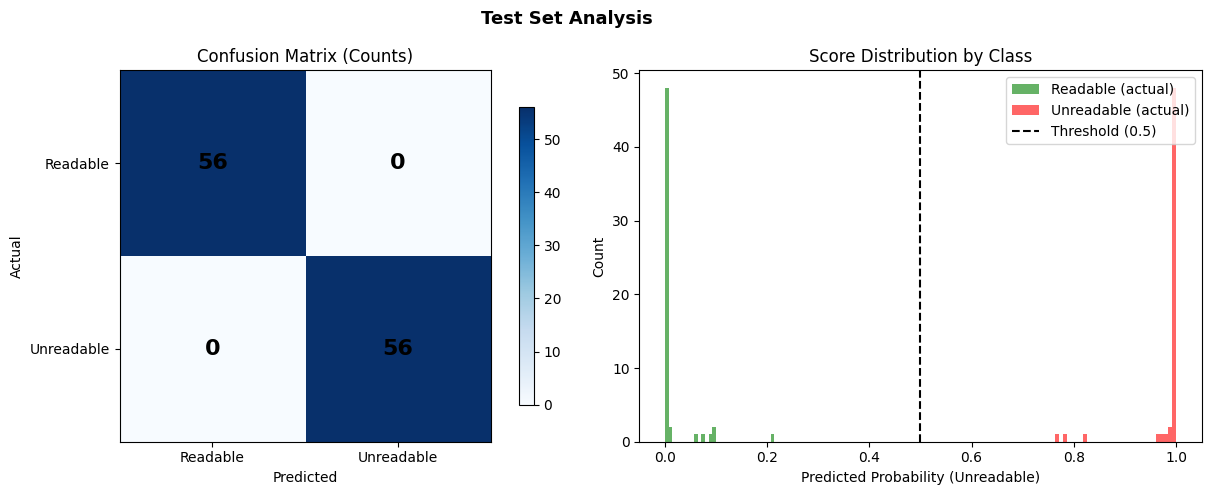

In [40]:
# === Confusion Matrix ===

cm = confusion_matrix(test_labels, test_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
im = ax1.imshow(cm, cmap='Blues', interpolation='nearest')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Readable', 'Unreadable'])
ax1.set_yticklabels(['Readable', 'Unreadable'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix (Counts)')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')
fig.colorbar(im, ax=ax1, shrink=0.8)

# Probability distribution
ax2.hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label='Readable (actual)', color='green')
ax2.hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label='Unreadable (actual)', color='red')
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax2.set_xlabel('Predicted Probability (Unreadable)')
ax2.set_ylabel('Count')
ax2.set_title('Score Distribution by Class')
ax2.legend()

plt.suptitle('Test Set Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'test_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7b. Threshold Optimization

Default threshold 0.5 belum tentu optimal. Kita cari threshold yang memaksimalkan F1-score pada **validation set** (bukan test set, untuk menghindari data leakage), lalu evaluasi hasilnya di test set.

Pertimbangan bisnis:
- **False Negative** (readable diklasifikasi unreadable) → mahasiswa diminta foto ulang padahal sudah bagus → annoying tapi tidak fatal
- **False Positive** (unreadable diklasifikasi readable) → dokumen tidak terbaca diterima → fatal

Maka kita **slightly bias ke higher threshold** (lebih ketat) untuk meminimalkan false positive.

THRESHOLD OPTIMIZATION (Validation Set)
  Best F1 threshold:  0.07
  F1 at best:         0.9912
  Precision at best:  0.9825
  Recall at best:     1.0000
  Default (0.50) F1:  0.9910

  Test F1 (default 0.5):      1.0000
  Test F1 (optimized 0.07):  0.9573
  Improvement:                -4.27%


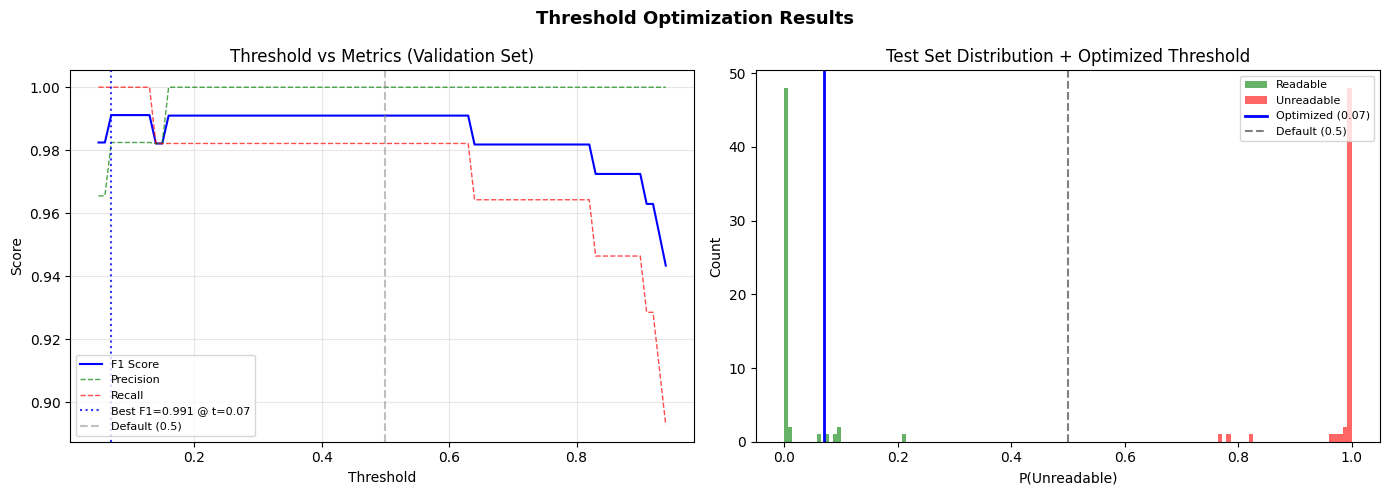


  → Use CLF_THRESHOLD=0.07 in deployment config


In [41]:
# === Threshold Optimization on Validation Set ===

# Get val predictions
_, _, val_probs, val_labels = evaluate(model, val_loader, criterion, DEVICE)

# Sweep thresholds
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    f1 = f1_score(val_labels, preds_t, zero_division=0)
    prec = np.sum((preds_t == 1) & (val_labels == 1)) / max(np.sum(preds_t == 1), 1)
    rec = np.sum((preds_t == 1) & (val_labels == 1)) / max(np.sum(val_labels == 1), 1)
    f1_scores.append(f1)
    precisions.append(prec)
    recalls.append(rec)

f1_scores = np.array(f1_scores)
precisions = np.array(precisions)
recalls = np.array(recalls)

# Best F1 threshold
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

print("=" * 55)
print("THRESHOLD OPTIMIZATION (Validation Set)")
print("=" * 55)
print(f"  Best F1 threshold:  {best_threshold:.2f}")
print(f"  F1 at best:         {best_f1:.4f}")
print(f"  Precision at best:  {precisions[best_f1_idx]:.4f}")
print(f"  Recall at best:     {recalls[best_f1_idx]:.4f}")
print(f"  Default (0.50) F1:  {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}")

# ── Evaluate optimized threshold on TEST set ────────────────────────
test_preds_opt = (test_probs >= best_threshold).astype(int)
test_f1_opt = f1_score(test_labels, test_preds_opt)
test_f1_default = f1_score(test_labels, (test_probs >= 0.5).astype(int))

print(f"\n  Test F1 (default 0.5):      {test_f1_default:.4f}")
print(f"  Test F1 (optimized {best_threshold:.2f}):  {test_f1_opt:.4f}")
print(f"  Improvement:                {(test_f1_opt - test_f1_default)*100:+.2f}%")

# ── Plot ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 vs Threshold
ax1.plot(thresholds, f1_scores, 'b-', linewidth=1.5, label='F1 Score')
ax1.plot(thresholds, precisions, 'g--', linewidth=1, alpha=0.7, label='Precision')
ax1.plot(thresholds, recalls, 'r--', linewidth=1, alpha=0.7, label='Recall')
ax1.axvline(x=best_threshold, color='blue', linestyle=':', alpha=0.8,
            label=f'Best F1={best_f1:.3f} @ t={best_threshold:.2f}')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Threshold vs Metrics (Validation Set)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Score distribution with optimized threshold
ax2.hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label='Readable', color='green')
ax2.hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label='Unreadable', color='red')
ax2.axvline(x=best_threshold, color='blue', linestyle='-', linewidth=2,
            label=f'Optimized ({best_threshold:.2f})')
ax2.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label='Default (0.5)')
ax2.set_xlabel('P(Unreadable)')
ax2.set_ylabel('Count')
ax2.set_title('Test Set Distribution + Optimized Threshold')
ax2.legend(fontsize=8)

plt.suptitle('Threshold Optimization Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Log to W&B ─────────────────────────────────────────────────────
wandb.log({
    "threshold/best": best_threshold,
    "threshold/best_f1": best_f1,
    "threshold/test_f1_default": test_f1_default,
    "threshold/test_f1_optimized": test_f1_opt,
})

# ── Store for use in pipeline config ────────────────────────────────
OPTIMAL_THRESHOLD = best_threshold
print(f"\n  → Use CLF_THRESHOLD={OPTIMAL_THRESHOLD:.2f} in deployment config")

In [42]:
# === Error Analysis: Misclassified Samples ===

misclassified = []
model.eval()

with torch.no_grad():
    for i, (img_path, label) in enumerate(test_dataset.samples):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMGSZ, IMGSZ))
        
        prob = test_probs[i]
        pred = test_preds[i]
        
        if pred != label:
            misclassified.append({
                'path': img_path,
                'true_label': label,
                'pred_prob': prob,
                'image': img_resized,
            })

print(f"Total misclassified: {len(misclassified)} / {len(test_dataset)} ({len(misclassified)/len(test_dataset)*100:.1f}%)")

if misclassified:
    n_show = min(8, len(misclassified))
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    for ax, item in zip(axes.flat, misclassified[:n_show]):
        ax.imshow(item['image'])
        true_name = 'Readable' if item['true_label'] == 0 else 'Unreadable'
        pred_name = 'Readable' if item['pred_prob'] < 0.5 else 'Unreadable'
        ax.set_title(
            f"True: {true_name}\nPred: {pred_name} ({item['pred_prob']:.3f})",
            fontsize=9, color='red'
        )
        ax.axis('off')
    
    for ax in axes.flat[n_show:]:
        ax.axis('off')
    
    plt.suptitle('Misclassified Samples (Error Analysis)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No misclassifications on test set.")

Total misclassified: 0 / 112 (0.0%)
No misclassifications on test set.


## 8. ONNX Export

### Export Strategy

Model di-wrap agar sigmoid sudah embedded di dalam graph ONNX:  
`input → MobileNetV3 → logit → sigmoid → probability`  

Ini memudahkan production: output langsung probabilitas 0~1, tinggal threshold.

In [43]:
# === Wrap Model with Sigmoid for ONNX ===

class ReadabilityClassifierExport(nn.Module):
    """
    Wrapper: MobileNetV3-Small + Sigmoid.
    Output: probability (0.0 ~ 1.0) bahwa gambar Unreadable.
    
    Threshold di production:
      prob < 0.5 → Readable (True, return image)
      prob >= 0.5 → Unreadable (False)
    """
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        logit = self.backbone(x)  # (B, 1)
        prob = self.sigmoid(logit) # (B, 1)
        return prob

# Build export model
export_model = ReadabilityClassifierExport(model)
export_model.eval()
export_model.to('cpu')

# Dummy input
dummy_input = torch.randn(1, 3, IMGSZ, IMGSZ)

# Quick test
with torch.no_grad():
    test_out = export_model(dummy_input)
    print(f"Export model test — Output shape: {test_out.shape}, value: {test_out.item():.4f}")

Export model test — Output shape: torch.Size([1, 1]), value: 0.6646


In [44]:
# === Export to ONNX ===
import onnx

ONNX_PATH = str(SAVE_DIR / 'readability_classifier.onnx')

torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    opset_version=17,
    input_names=['input'],
    output_names=['probability'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'probability': {0: 'batch_size'},
    },
    do_constant_folding=True,
)

# Verify
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)

print(f"\nONNX exported: {ONNX_PATH}")
print(f"   File size: {os.path.getsize(ONNX_PATH) / 1e6:.2f} MB")
print(f"   Opset: 17")

/tmp/ipykernel_4189/3951788251.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0506 12:53:17.163000 4189 .venv/lib/python3.13/site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ReadabilityClassifierExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ReadabilityClassifierExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/gradi/projects/MitBridge/.venv/lib64/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/home/gradi/projects/MitBridge/.venv/lib64/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/gradi/projects/MitBridge/.venv/lib64/python3.13/site-

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅

ONNX exported: runs/classification/document_readability/readability_classifier.onnx
   File size: 0.36 MB
   Opset: 17


In [45]:
# === Verify ONNX I/O ===
import onnxruntime as ort

session = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])

print("ONNX Model I/O:")
for inp in session.get_inputs():
    print(f"  Input:  {inp.name} | shape: {inp.shape} | dtype: {inp.type}")
for out in session.get_outputs():
    print(f"  Output: {out.name} | shape: {out.shape} | dtype: {out.type}")

# Cross-check: PyTorch vs ONNX output
dummy_np = dummy_input.numpy()
onnx_out = session.run(None, {'input': dummy_np})[0]
torch_out = test_out.numpy()

diff = np.abs(onnx_out - torch_out).max()
print(f"\nPyTorch vs ONNX max diff: {diff:.8f}")
print(f"Match: {'Yes' if diff < 1e-5 else 'No'}")

ONNX Model I/O:
  Input:  input | shape: ['batch_size', 3, 224, 224] | dtype: tensor(float)
  Output: probability | shape: ['batch_size', 1] | dtype: tensor(float)

PyTorch vs ONNX max diff: 0.00000042
Match: Yes


## 9. ONNX Runtime Inference Pipeline (Production-Ready)

Pipeline ini menerima gambar hasil warp+CLAHE dari Model 1 (atau dari production pipeline).  
**Flow:** Warped Image → CLAHE (jika belum) → Resize 224 → Normalize → ONNX Inference → Probability → Boolean

In [46]:
# === Production Inference Class ===

class ReadabilityClassifierONNX:
    """
    MobileNetV3-Small Readability Classifier menggunakan ONNX Runtime.
    
    Input:  BGR image (warped document, any resolution)
    Output: dict {readable: bool, probability: float}
    
    Pipeline:
      BGR → Grayscale → CLAHE → BGR → Resize 224 → Normalize (ImageNet) → Inference
    """
    
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    
    def __init__(self, model_path, imgsz=224, threshold=0.5):
        self.imgsz = imgsz
        self.threshold = threshold
        self.session = ort.InferenceSession(
            model_path,
            providers=['CPUExecutionProvider'],
        )
        self.input_name = self.session.get_inputs()[0].name
        
        # CLAHE instance (match production pipeline)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    def preprocess_clahe(self, image_bgr):
        """
        Grayscale → CLAHE → BGR.
        Identical to preprocess_for_model2() di augment.py.
        """
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        clahe_img = self.clahe.apply(gray)
        bgr_out = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2BGR)
        return bgr_out
    
    def preprocess_for_inference(self, image_bgr, apply_clahe=True):
        """
        Full preprocessing: CLAHE (optional) → Resize → Normalize → CHW → Batch.
        
        Args:
            image_bgr: Input image (BGR, any resolution)
            apply_clahe: Set False jika gambar sudah CLAHE-preprocessed
        
        Returns:
            blob: np.array (1, 3, 224, 224) float32
        """
        if apply_clahe:
            image_bgr = self.preprocess_clahe(image_bgr)
        
        # Resize
        resized = cv2.resize(image_bgr, (self.imgsz, self.imgsz), interpolation=cv2.INTER_LINEAR)
        
        # BGR → RGB, normalize to 0~1
        rgb = resized[:, :, ::-1].astype(np.float32) / 255.0
        
        # ImageNet normalization
        rgb = (rgb - self.IMAGENET_MEAN) / self.IMAGENET_STD
        
        # HWC → CHW, add batch
        blob = np.transpose(rgb, (2, 0, 1))   # (3, 224, 224)
        blob = np.expand_dims(blob, axis=0)     # (1, 3, 224, 224)
        blob = np.ascontiguousarray(blob)
        
        return blob
    
    def classify(self, image_bgr, apply_clahe=True):
        """
        Main classification pipeline.
        
        Args:
            image_bgr: BGR image (warped document from Model 1)
            apply_clahe: True di production (raw warped), False jika sudah CLAHE
            
        Returns:
            dict:
                'readable': bool (True = teks bisa dibaca)
                'probability_unreadable': float (0.0 ~ 1.0)
        """
        blob = self.preprocess_for_inference(image_bgr, apply_clahe=apply_clahe)
        
        outputs = self.session.run(None, {self.input_name: blob})
        prob_unreadable = float(outputs[0][0][0])
        
        return {
            'readable': prob_unreadable < self.threshold,
            'probability_unreadable': prob_unreadable,
        }

print("ReadabilityClassifierONNX class defined")

ReadabilityClassifierONNX class defined


## 10. End-to-End Integration Test

In [47]:
# === Benchmark Inference Time ===

classifier = ReadabilityClassifierONNX(
    model_path=ONNX_PATH,
    imgsz=IMGSZ,
    threshold=0.55,
)

# Warmup
dummy = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)
for _ in range(5):
    classifier.classify(dummy, apply_clahe=True)

# Benchmark pada test set images
bench_samples = random.sample(test_dataset.samples, min(50, len(test_dataset.samples)))
times = []

for img_path, _ in bench_samples:
    img = cv2.imread(img_path)
    t0 = time.perf_counter()
    result = classifier.classify(img, apply_clahe=False)  # Already CLAHE'd
    t1 = time.perf_counter()
    times.append(t1 - t0)

times_ms = np.array(times) * 1000
print("ONNX Inference Benchmark (CPU):")
print(f"  Mean:   {times_ms.mean():.1f} ms")
print(f"  Median: {np.median(times_ms):.1f} ms")
print(f"  P95:    {np.percentile(times_ms, 95):.1f} ms")
print(f"  Min:    {times_ms.min():.1f} ms")
print(f"  Max:    {times_ms.max():.1f} ms")

ONNX Inference Benchmark (CPU):
  Mean:   4.8 ms
  Median: 3.4 ms
  P95:    13.2 ms
  Min:    2.8 ms
  Max:    13.4 ms


In [48]:
# === ONNX vs PyTorch Consistency Check ===
# Pastikan ONNX output match PyTorch untuk semua test samples

model.eval()
model.to('cpu')
max_diff = 0.0
n_check = min(100, len(test_dataset))

for i in range(n_check):
    img_tensor, label = test_dataset[i]
    
    # PyTorch
    with torch.no_grad():
        pt_logit = model(img_tensor.unsqueeze(0))
        pt_prob = torch.sigmoid(pt_logit).item()
    
    # ONNX
    onnx_input = img_tensor.unsqueeze(0).numpy()
    onnx_prob = session.run(None, {'input': onnx_input})[0][0][0]
    
    diff = abs(pt_prob - onnx_prob)
    max_diff = max(max_diff, diff)

print(f"PyTorch vs ONNX consistency check ({n_check} samples):")
print(f"  Max absolute difference: {max_diff:.8f}")
print(f"  Status: {'Match' if max_diff < 1e-4 else '⚠Mismatch detected'}")

model.to(DEVICE);

PyTorch vs ONNX consistency check (100 samples):
  Max absolute difference: 0.00000211
  Status: Match


/tmp/ipykernel_4189/2711436406.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gradi/projects/MitBridge/.venv/lib64/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


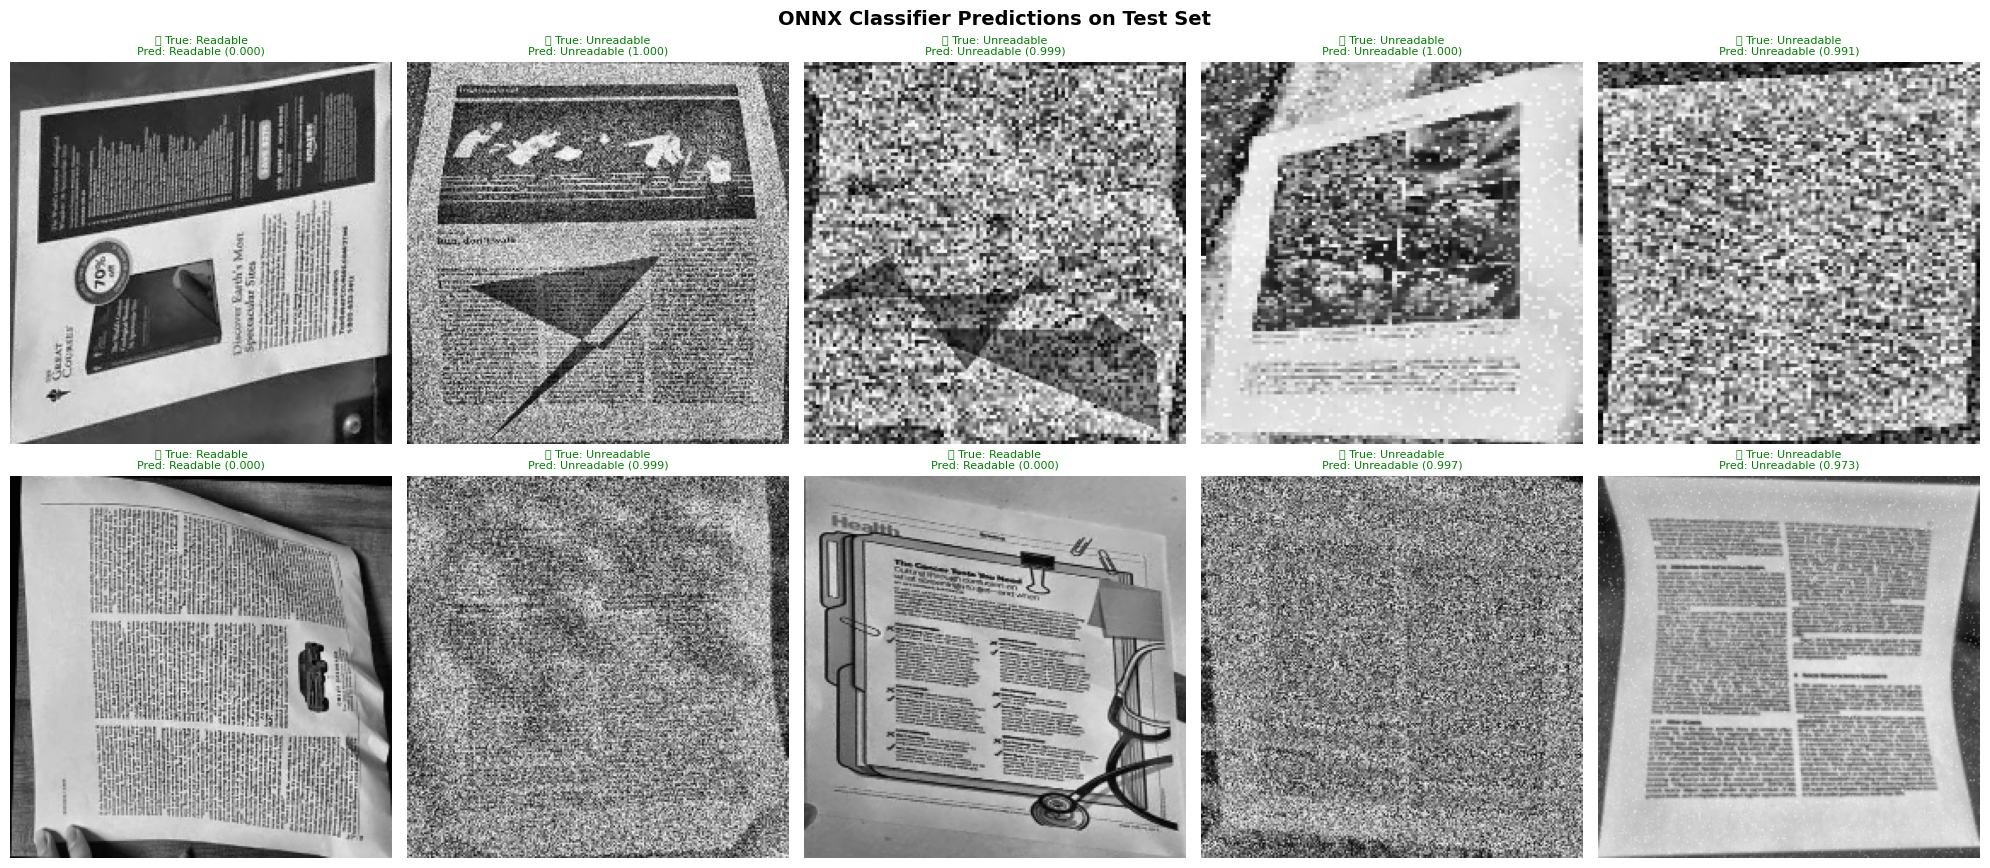

In [49]:
# === Visual Test: Predictions on Test Samples ===

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
vis_samples = random.sample(test_dataset.samples, min(10, len(test_dataset.samples)))

for ax, (img_path, true_label) in zip(axes.flat, vis_samples):
    img = cv2.imread(img_path)
    result = classifier.classify(img, apply_clahe=False)  # Already CLAHE'd
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_show = cv2.resize(img_rgb, (224, 224))
    ax.imshow(img_show)
    
    true_name = 'Readable' if true_label == 0 else 'Unreadable'
    pred_name = 'Readable' if result['readable'] else 'Unreadable'
    correct = (true_label == 0) == result['readable']
    
    color = 'green' if correct else 'red'
    symbol = '✅' if correct else '❌'
    ax.set_title(
        f"{symbol} True: {true_name}\nPred: {pred_name} ({result['probability_unreadable']:.3f})",
        fontsize=8, color=color,
    )
    ax.axis('off')

plt.suptitle('ONNX Classifier Predictions on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# === Full Pipeline Simulation ===
# Simulasi chain: Model 1 (OBB) → Model 2 (Classification)

print("\n" + "=" * 65)
print("FULL PIPELINE SIMULATION")
print("=" * 65)
print("\nAssuming Model 1 returns a warped document image...")
print("")

# Simulasi: ambil gambar dari test set sebagai "warped document"
for img_path, true_label in random.sample(test_dataset.samples, 3):
    img = cv2.imread(img_path)
    
    print(f"  Input: {Path(img_path).name}")
    
    # Step 1: CLAHE preprocessing (di production, dilakukan setelah warp)
    # (skip karena data test sudah CLAHE'd)
    
    # Step 2: Classification
    result = classifier.classify(img, apply_clahe=False)
    
    if result['readable']:
        print(f"    → READABLE (prob_unreadable={result['probability_unreadable']:.4f})")
        print(f"    → Return: True + warped image ({img.shape[1]}×{img.shape[0]})")
    else:
        print(f"    → UNREADABLE (prob_unreadable={result['probability_unreadable']:.4f})")
        print(f"    → Return: False")
    print()


FULL PIPELINE SIMULATION

Assuming Model 1 returns a warped document image...

  Input: R_0032_jpg.rf.a7cb7476d9bba2a345363eb1bd666453_crop_0_var.jpg
    → READABLE (prob_unreadable=0.0000)
    → Return: True + warped image (325×450)

  Input: 58_1_JPG_jpg.rf.703f53f464c850bd43bd662cb2c12e2d_crop_0_bad_0.jpg
    → UNREADABLE (prob_unreadable=1.0000)
    → Return: False

  Input: 0000_random-158-_jpg.rf.52b58a0e24db88629b237de2efb0e98d_crop_0_clean.jpg
    → READABLE (prob_unreadable=0.0001)
    → Return: True + warped image (437×486)



In [51]:
# === Final Summary ===

print("\n" + "=" * 65)
print("MODEL 2 (MobileNetV3-Small) TRAINING SUMMARY")
print("=" * 65)
print(f"\n  Weights (PyTorch): {SAVE_DIR / 'best.pt'}")
print(f"  Weights (ONNX):    {ONNX_PATH}")
print(f"  ONNX Size:         {os.path.getsize(ONNX_PATH) / 1e6:.2f} MB")
print(f"  Input:             {IMGSZ}×{IMGSZ} RGB (ImageNet-normalized)")
print(f"  Output:            probability_unreadable (0.0 ~ 1.0)")
print(f"  Sigmoid:           Embedded in ONNX graph")
print(f"  Inference (CPU):   ~{times_ms.mean():.0f} ms")
print(f"\n  Optuna HPO:        {N_TRIALS} trials")
print(f"  Best HPO ROC-AUC:  {study.best_value:.4f}")
for k, v in BEST_HP.items():
    print(f"    {k}: {v}")
print(f"\n  Optimal Threshold: {OPTIMAL_THRESHOLD:.2f}")
print(f"  Test Accuracy:     {test_acc:.4f}")
print(f"  Test ROC-AUC:      {roc_auc_score(test_labels, test_probs):.4f}")
print(f"  Test PR-AUC:       {pr_auc:.4f}")
print(f"  Test F1 (opt):     {test_f1_opt:.4f}")
print(f"\n  Pipeline Chain:")
print(f"    Warped Image (from Model 1)")
print(f"    ├─ CLAHE preprocessing")
print(f"    ├─ MobileNetV3-Small inference")
print(f"    ├─ prob < {OPTIMAL_THRESHOLD:.2f} → Readable  → return True + image")
print(f"    └─ prob ≥ {OPTIMAL_THRESHOLD:.2f} → Unreadable → return False")
print("\n" + "=" * 65)

# ── Close W&B ───────────────────────────────────────────────────────
wandb.finish()

wandb: updating run metadata



MODEL 2 (MobileNetV3-Small) TRAINING SUMMARY

  Weights (PyTorch): runs/classification/document_readability/best.pt
  Weights (ONNX):    runs/classification/document_readability/readability_classifier.onnx
  ONNX Size:         0.36 MB
  Input:             224×224 RGB (ImageNet-normalized)
  Output:            probability_unreadable (0.0 ~ 1.0)
  Sigmoid:           Embedded in ONNX graph
  Inference (CPU):   ~5 ms

  Optuna HPO:        20 trials
  Best HPO ROC-AUC:  1.0000
    dropout: 0.5
    batch_size: 32
    weight_decay: 0.0001905080855737911
    p1_lr: 0.0005844043311479347
    p2_lr_backbone: 0.000380105401668463
    p2_lr_head: 0.00028166131254415554

  Optimal Threshold: 0.07
  Test Accuracy:     1.0000
  Test ROC-AUC:      1.0000
  Test PR-AUC:       1.0000
  Test F1 (opt):     0.9573

  Pipeline Chain:
    Warped Image (from Model 1)
    ├─ CLAHE preprocessing
    ├─ MobileNetV3-Small inference
    ├─ prob < 0.07 → Readable  → return True + image
    └─ prob ≥ 0.07 → Unreada

wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:                       epoch ▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
wandb:                          lr █▇▇▆▅▃▂▂▁▁
wandb:                 lr_backbone ███▇▇▆▅▅▄▃▂▁
wandb:                     lr_head ███▇▇▆▅▅▄▃▂▁
wandb:                       phase ▁▁▁▁▁▁▁▁▁▁████████████
wandb:              threshold/best ▁
wandb:           threshold/best_f1 ▁
wandb:   threshold/test_f1_default ▁
wandb: threshold/test_f1_optimized ▁
wandb:                   train/acc ▁▅▆▇▇▇▇█▇▇▅▇▇▇████████
wandb:                          +4 ...
wandb: 
wandb: Run summary:
wandb:                       epoch 22
wandb:                          lr 0
wandb:                 lr_backbone 0.00025
wandb:                     lr_head 0.00018
wandb:                       phase 2
wandb:              threshold/best 0.07
wandb:           threshold/best_f1 0.99115
wandb:   threshold/test_f1_default 1
wandb: threshold/test_f1_optimized 0.95726
wandb:                   train/acc 0.99414
wandb:  